
![1 PM5Q-58eNOWdoLogVKCGnQ.webp](<attachment:1 PM5Q-58eNOWdoLogVKCGnQ.webp>)
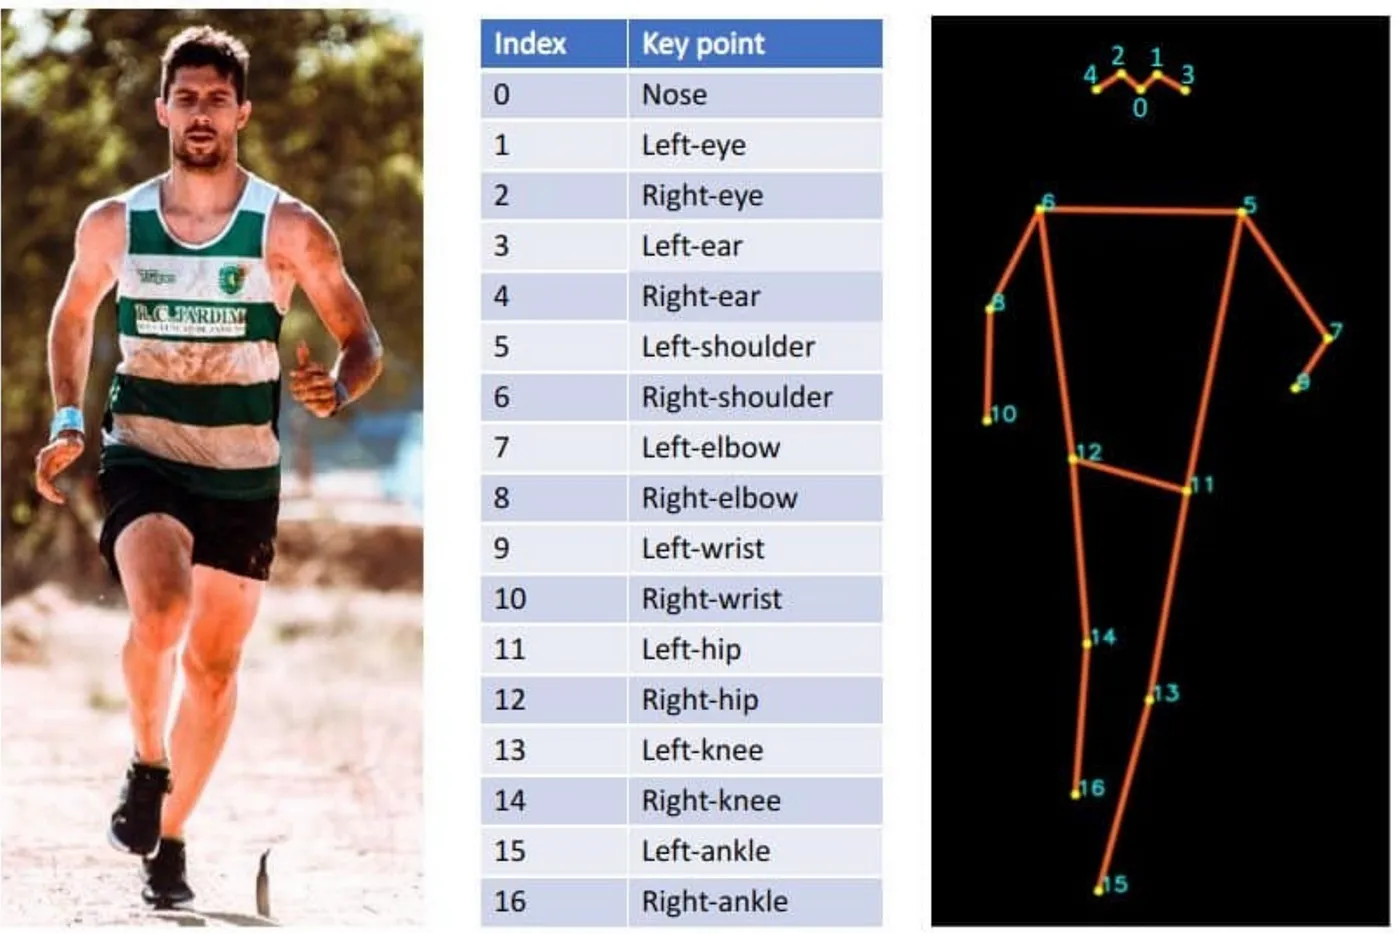

Yolov8s
Para instalarlo: pip install -U ultralytics

pip install lapx


In [ ]:
import torch
import cv2
from ultralytics import YOLO
# Model
model = YOLO('yolov8x-pose-p6.pt')
#model=YOLO('yolov8n-pose.pt') más rápido
# Images
video = cv2.VideoCapture("people2.mp4")

success, frame = video.read()
size=(frame.shape[1], frame.shape[0])
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
video_out = cv2.VideoWriter('yolo_pose.mp4', fourcc, 30.0, size)

# Bucle a través de los fotogramas del video
while (success):
    puntos =[]
   
    # Ejecutar seguimiento YOLOv8 en el fotograma, persistiendo los rastreos entre fotogramas
    results = model.track(frame)[0]
   
    for r in results:
        kpts = r.keypoints
        nk = kpts.shape[1]
        for i in range(nk):
            keypoint=kpts.xy[0,i]    
            x, y = (int(keypoint[0])),(int(keypoint[1]))
            puntos.append([x,y])
            cv2.circle(frame, (x,y),5,(0,255,0),-1)
                
    # Mostrar el fotograma anotado
    cv2.imshow('salida',frame)
    video_out.write(frame)
    success, frame = video.read()
    # Romper el bucle si se presiona 'q'
    if cv2.waitKey(1) & 0xFF == ord("q"):
         success = False
         break
    

# Liberar el objeto de captura de video y cerrar la ventana de visualización
video.release()
video_out.release()
cv2.destroyAllWindows()

ModuleNotFoundError: No module named 'cv2'